In [4]:
!pip install kmodes

In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes
from kmodes.kmodes import KModes
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import KBinsDiscretizer

In [8]:
df_frequency = pd.read_csv("consulting/frequency2.csv")

In [9]:
df_frequency.head()

,uwYear,gender,carType,carCat,job,age,nYears,carVal,cover,density,claimNumbMD,age_bucket,age_cluster_code,age_cluster,carVal_cluster_code,carVal_cluster,density_cluster_code,density_cluster
0,2009,Male,C,Large,Employed,25,3,15080,0,72.012883,1,"(21.0, 25.0]",0.0,18 - 35,1.0,"€15,076 - €31,188",0.0,14 - 97 inh/km²
1,2009,Male,E,Large,Employed,20,2,22370,1,39.550411,1,"(17.999, 21.0]",0.0,18 - 35,1.0,"€15,076 - €31,188",0.0,14 - 97 inh/km²
2,2009,Female,E,Large,Unemployed,42,0,39650,0,169.529148,1,"(41.0, 45.0]",1.0,35 - 53,2.0,"€31,188 - €49,995",1.0,97 - 193 inh/km²
3,2009,Female,C,Medium,Housewife,21,0,12600,1,58.894688,1,"(17.999, 21.0]",0.0,18 - 35,0.0,"€1,000 - €15,076",0.0,14 - 97 inh/km²
4,2009,Female,D,Large,Employed,33,10,9065,0,109.631885,1,"(29.0, 33.0]",0.0,18 - 35,0.0,"€1,000 - €15,076",1.0,97 - 193 inh/km²


In [10]:
df_severity = pd.read_csv("consulting/severity2.csv")

In [11]:
df_severity.head()

,uwYear,gender,carType,carCat,job,age,nYears,carVal,cover,density,claimSizeMD,age_bucket,age_cluster_code,age_cluster,carVal_cluster_code,carVal_cluster,density_cluster_code,density_cluster
0,2009,Female,A,Medium,Housewife,41,0,24940,1,273,740,"(36.0, 41.0]",1.0,35 - 53,1.0,"€15,076 - €31,188",2.0,193 - 297 inh/km²
1,2009,Male,B,Small,Unemployed,25,12,48945,0,190,207,"(23.0, 25.0]",0.0,18 - 35,2.0,"€31,188 - €49,995",1.0,97 - 193 inh/km²
2,2009,Female,E,Small,Employed,29,7,1525,0,225,803,"(28.0, 32.0]",0.0,18 - 35,0.0,"€1,000 - €15,076",2.0,193 - 297 inh/km²
3,2009,Male,A,Small,Self-employed,47,12,18480,1,129,868,"(46.0, 54.0]",1.0,35 - 53,1.0,"€15,076 - €31,188",1.0,97 - 193 inh/km²
4,2009,Female,C,Large,Employed,47,7,8690,0,290,1746,"(46.0, 54.0]",1.0,35 - 53,0.0,"€1,000 - €15,076",2.0,193 - 297 inh/km²


## Frequency Model

In [12]:
formula_freq = (
    "claimNumbMD ~ gender + carType + carCat + job + nYears + age * density + carVal"
)

In [13]:
model_freq = smf.glm(
    formula=formula_freq, data=df_frequency, family=sm.families.Poisson()
).fit()

In [14]:
print(model_freq.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claimNumbMD   No. Observations:                24753
Model:                            GLM   Df Residuals:                    24736
Model Family:                 Poisson   Df Model:                           16
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -20165.
Date:                Sun, 03 May 2026   Deviance:                       15817.
Time:                        10:14:14   Pearson chi2:                 1.26e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.05549
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.3532 

so `carCat` doesn't seem to be significant at all. I'm gonna drop it

In [15]:
formula_freq_v2 = (
    "claimNumbMD ~ gender + carType + job + nYears + age * density + carVal"
)

In [16]:
model_freq_v2 = smf.glm(
    formula=formula_freq_v2, data=df_frequency, family=sm.families.Poisson()
).fit()

In [17]:
print(model_freq_v2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claimNumbMD   No. Observations:                24753
Model:                            GLM   Df Residuals:                    24738
Model Family:                 Poisson   Df Model:                           14
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -20165.
Date:                Sun, 03 May 2026   Deviance:                       15819.
Time:                        10:14:20   Pearson chi2:                 1.26e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.05543
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.3579 

the is no significant difference between the car types **A** and **B**. Also, `carVal` practically has no effect on severity

## Severity Model

In [18]:
formula_sev = (
    "claimSizeMD ~ gender + carType + carCat + job + nYears + age * density + carVal"
)

In [19]:
model_sev = smf.glm(
    formula=formula_sev,
    data=df_severity,
    family=sm.families.Gamma(link=sm.families.links.Log()),
).fit()

In [20]:
print(model_sev.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claimSizeMD   No. Observations:                12256
Model:                            GLM   Df Residuals:                    12239
Model Family:                   Gamma   Df Model:                           16
Link Function:                    Log   Scale:                          1.0630
Method:                          IRLS   Log-Likelihood:                    inf
Date:                Sun, 03 May 2026   Deviance:                       14599.
Time:                        10:14:44   Pearson chi2:                 1.30e+04
No. Iterations:                    20   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                6.8903 

C:\Users\athul\anaconda3\envs\lego-project\lib\site-packages\statsmodels\genmod\families\family.py:812: RuntimeWarning: divide by zero encountered in log
  ll_obs -= special.gammaln(weight_scale) + np.log(endog)
C:\Users\athul\anaconda3\envs\lego-project\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1891: RuntimeWarning: invalid value encountered in scalar subtract
  prsq = 1 - np.exp((self.llnull - self.llf) * (2 / self.nobs))


In [21]:
(df_severity["claimSizeMD"] == 0).any()

True

there are some zero values for the target in the severity data. we should handle that.
Also dropping the carCat covariate.

In [22]:
df_severity_clean = df_severity[df_severity["claimSizeMD"] > 0].copy()

In [23]:
formula_sev_v2 = (
    "claimSizeMD ~ gender + carType + job + nYears + age * density + carVal"
)

In [24]:
model_sev_v2 = smf.glm(
    formula=formula_sev_v2,
    data=df_severity_clean,
    family=sm.families.Gamma(link=sm.families.links.Log()),
).fit()

In [25]:
print(model_sev_v2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claimSizeMD   No. Observations:                12252
Model:                            GLM   Df Residuals:                    12237
Model Family:                   Gamma   Df Model:                           14
Link Function:                    Log   Scale:                          1.0621
Method:                          IRLS   Log-Likelihood:                -94612.
Date:                Sun, 03 May 2026   Deviance:                       14320.
Time:                        10:14:51   Pearson chi2:                 1.30e+04
No. Iterations:                    15   Pseudo R-squ. (CS):            0.07768
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                6.8748 

`carVal`, and the age and density interaction don't seem to be important in the severity of the claim. dropping these covariates and refitting the model

In [26]:
formula_sev_v3 = "claimSizeMD ~ gender + carType + job + nYears + age + density"

In [27]:
model_sev_v3 = smf.glm(
    formula=formula_sev_v3,
    data=df_severity_clean,
    family=sm.families.Gamma(link=sm.families.links.Log()),
).fit()

In [28]:
print(model_sev_v3.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claimSizeMD   No. Observations:                12252
Model:                            GLM   Df Residuals:                    12239
Model Family:                   Gamma   Df Model:                           12
Link Function:                    Log   Scale:                          1.0625
Method:                          IRLS   Log-Likelihood:                -94614.
Date:                Sun, 03 May 2026   Deviance:                       14324.
Time:                        10:14:54   Pearson chi2:                 1.30e+04
No. Iterations:                    15   Pseudo R-squ. (CS):            0.07735
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                6.9588 

## Combining the results

In [29]:
df_frequency["Expected_Frequency"] = model_freq_v2.predict(df_frequency)

In [30]:
df_frequency["Expected_Severity"] = model_sev_v3.predict(df_frequency)

In [31]:
df_frequency["Expected_Cost"] = (
    df_frequency["Expected_Frequency"] * df_frequency["Expected_Severity"]
)

In [32]:
df_frequency[["Expected_Frequency", "Expected_Severity", "Expected_Cost"]]

,Expected_Frequency,Expected_Severity,Expected_Cost
0,0.575463,840.618232,483.744413
1,0.683350,765.991802,523.440541
2,0.623745,789.649224,492.539905
3,0.612203,693.887694,424.799942
4,0.448509,621.263210,278.641892
...,...,...,...
24748,0.666291,953.782692,635.496792
24749,0.560749,769.680552,431.597462
24750,0.124768,629.122430,78.494271
24751,0.613144,809.684920,496.453332


In [33]:
cols_to_show = [
    "gender",
    "age",
    "carType",
    "job",
    "density",
    "Expected_Cost",
]

In [34]:
summary_df = df_frequency[cols_to_show].copy()

In [35]:
summary_df["Expected_Cost"] = summary_df["Expected_Cost"].apply(
    lambda x: f"€{x:,.2f}" if isinstance(x, (int, float)) else x
)

In [36]:
summary_df

,gender,age,carType,job,density,Expected_Cost
0,Male,25,C,Employed,72.012883,€483.74
1,Male,20,E,Employed,39.550411,€523.44
2,Female,42,E,Unemployed,169.529148,€492.54
3,Female,21,C,Housewife,58.894688,€424.80
4,Female,33,D,Employed,109.631885,€278.64
...,...,...,...,...,...,...
24748,Male,22,D,Unemployed,23.218206,€635.50
24749,Female,26,E,Unemployed,22.241294,€431.60
24750,Female,74,E,Retired,32.390521,€78.49
24751,Male,24,E,Employed,145.223003,€496.45


## Building the Risk Tier

In [37]:
premiums = df_frequency[["Expected_Cost"]].copy()

In [38]:
inertia_values = []
K_range = range(2, 9)

for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=25)
    kmeans_test.fit(premiums)
    inertia_values.append(kmeans_test.inertia_)

    print(f"Tested k = {k}, Inertia: {kmeans_test.inertia_:,.0f}")

Tested k = 2, Inertia: 449,611,761
Tested k = 3, Inertia: 230,343,586
Tested k = 4, Inertia: 139,548,928
Tested k = 5, Inertia: 92,174,711
Tested k = 6, Inertia: 65,543,706
Tested k = 7, Inertia: 48,900,001
Tested k = 8, Inertia: 38,600,823


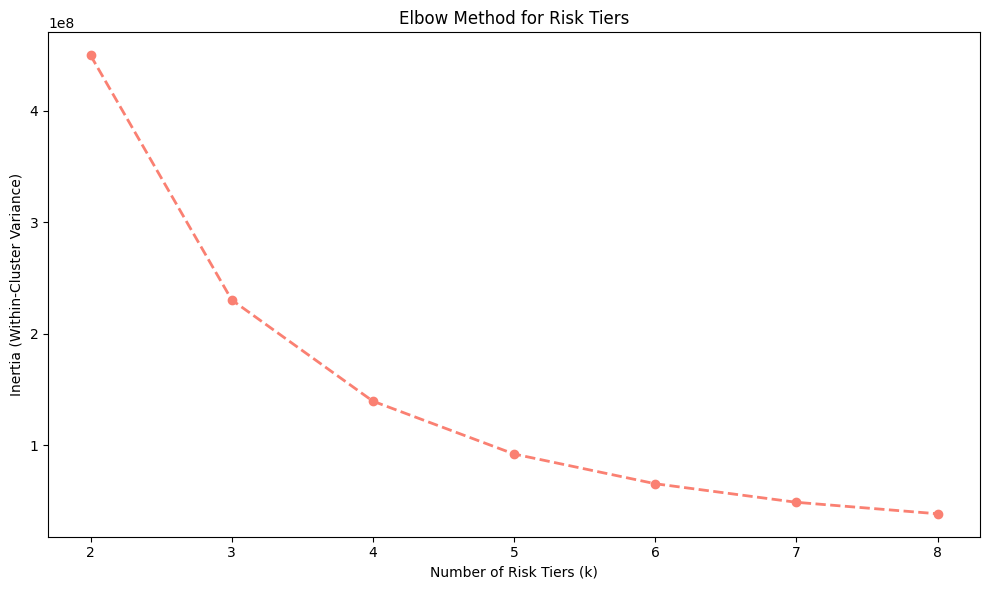

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    K_range, inertia_values, marker="o", linestyle="--", color="salmon", linewidth=2
)
ax.set_title("Elbow Method for Risk Tiers")
ax.set_xlabel("Number of Risk Tiers (k)")
ax.set_ylabel("Inertia (Within-Cluster Variance)")

fig.tight_layout()

In [40]:
OPTIMUM_NUM_K = 3

In [41]:
discretizer = KBinsDiscretizer(
    n_bins=OPTIMUM_NUM_K, encode="ordinal", strategy="kmeans", random_state=36
)

In [42]:
binned_premiums = discretizer.fit_transform(premiums)

In [43]:
risk_labels = {0.0: "Low Risk", 1.0: "Medium Risk", 2.0: "High Risk"}

In [44]:
df_frequency["risk_flag"] = pd.Series(binned_premiums.flatten()).map(risk_labels)

In [45]:
edges = discretizer.bin_edges_[0]
print("EXACT EURO BOUNDARIES:\n")
print(f"Low Risk: Up to €{edges[1]:,.2f}")
print(f"Medium Risk: €{edges[1]:,.2f} to €{edges[2]:,.2f}")
print(f"High Risk: Above €{edges[2]:,.2f}\n")

EXACT EURO BOUNDARIES:

Low Risk: Up to €381.87
Medium Risk: €381.87 to €690.78
High Risk: Above €690.78



In [46]:
risk_summary = (
    df_frequency.groupby("risk_flag")
    .agg(
        Customer_Count=("risk_flag", "count"),
        Minimum_Premium=("Expected_Cost", "min"),
        Maximum_Premium=("Expected_Cost", "max"),
        Median_Premium=("Expected_Cost", "median"),
    )
    .reset_index()
)

In [47]:
for col in ["Minimum_Premium", "Maximum_Premium", "Median_Premium"]:
    risk_summary[col] = risk_summary[col].apply(lambda x: f"€{x:,.2f}")

In [48]:
risk_summary.sort_values(by="Customer_Count", ascending=False)

,risk_flag,Customer_Count,Minimum_Premium,Maximum_Premium,Median_Premium
1,Low Risk,12383,€50.31,€381.86,€256.99
2,Medium Risk,9175,€381.88,€690.76,€497.89
0,High Risk,3195,€690.83,"€1,693.82",€819.48


In [49]:
df_frequency.head()

,uwYear,gender,carType,carCat,job,age,nYears,carVal,cover,density,...,age_cluster_code,age_cluster,carVal_cluster_code,carVal_cluster,density_cluster_code,density_cluster,Expected_Frequency,Expected_Severity,Expected_Cost,risk_flag
0,2009,Male,C,Large,Employed,25,3,15080,0,72.012883,...,0.0,18 - 35,1.0,"€15,076 - €31,188",0.0,14 - 97 inh/km²,0.575463,840.618232,483.744413,Medium Risk
1,2009,Male,E,Large,Employed,20,2,22370,1,39.550411,...,0.0,18 - 35,1.0,"€15,076 - €31,188",0.0,14 - 97 inh/km²,0.683350,765.991802,523.440541,Medium Risk
2,2009,Female,E,Large,Unemployed,42,0,39650,0,169.529148,...,1.0,35 - 53,2.0,"€31,188 - €49,995",1.0,97 - 193 inh/km²,0.623745,789.649224,492.539905,Medium Risk
3,2009,Female,C,Medium,Housewife,21,0,12600,1,58.894688,...,0.0,18 - 35,0.0,"€1,000 - €15,076",0.0,14 - 97 inh/km²,0.612203,693.887694,424.799942,Medium Risk
4,2009,Female,D,Large,Employed,33,10,9065,0,109.631885,...,0.0,18 - 35,0.0,"€1,000 - €15,076",1.0,97 - 193 inh/km²,0.448509,621.263210,278.641892,Low Risk


In [50]:
continuous_cols = [
    "age",
    "nYears",
    "carVal",
    "density",
    "Expected_Frequency",
    "Expected_Severity",
    "Expected_Cost",
]
categorical_cols = ["gender", "job", "carType", "carCat"]

In [51]:
def profile_tier_medians(group):
    total_customers = len(group)
    profile = {"Portfolio_Size": total_customers}

    for col in continuous_cols:
        if col in group.columns:
            val = group[col].median()

            if "Val" in col or "Cost" in col or "Severity" in col:
                profile[f"Median_{col}"] = f"€{val:,.2f}"
            elif col == "density":
                profile[f"Median_{col}"] = f"{val:,.0f} inh/km²"
            elif col == "Expected_Frequency":
                profile[f"Median_{col}"] = f"{val:.4f}"
            else:
                profile[f"Median_{col}"] = round(val, 1)

    for col in categorical_cols:
        if col in group.columns:
            counts = group[col].value_counts()
            if not counts.empty:
                top_cat = counts.index[0]
                top_pct = (counts.iloc[0] / total_customers) * 100
                profile[f"Top_{col}"] = top_cat
                profile[f"%_{col}"] = f"{top_pct:.1f}%"

    return pd.Series(profile)

In [52]:
tier_profiles = (
    df_frequency.groupby("risk_flag").apply(profile_tier_medians).reset_index()
)

C:\Users\athul\AppData\Local\Temp\ipykernel_6776\586392967.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_frequency.groupby("risk_flag").apply(profile_tier_medians).reset_index()


In [53]:
tier_profiles.set_index("risk_flag").T

risk_flag,High Risk,Low Risk,Medium Risk
Portfolio_Size,3195,12383,9175
Median_age,23.0,46.0,29.0
Median_nYears,3.0,5.0,4.0
Median_carVal,"€16,385.00","€14,535.00","€15,235.00"
Median_density,225 inh/km²,69 inh/km²,140 inh/km²
Median_Expected_Frequency,0.7221,0.3919,0.5746
Median_Expected_Severity,"€1,175.55",€663.40,€877.26
Median_Expected_Cost,€819.48,€256.99,€497.89
Top_gender,Male,Male,Male
%_gender,82.1%,58.3%,70.3%


In [55]:
risk_labels = {0.0: "Low Risk", 1.0: "Medium Risk", 2.0: "High Risk"}


def score_new_customer_continuous(customer_data):
    df_input = pd.DataFrame(
        [
            {
                "gender": customer_data["gender"],
                "carType": customer_data["carType"],
                "carCat": customer_data["carCat"],
                "job": customer_data["job"],
                "nYears": customer_data["nYears"],
                "age": customer_data["age"],
                "density": customer_data["density"],
                "carVal": customer_data["carVal"],
            }
        ]
    )

    freq = model_freq_v2.predict(df_input).iloc[0]
    sev = model_sev_v3.predict(df_input).iloc[0]
    expected_cost = freq * sev

    cost_df = pd.DataFrame([[expected_cost]], columns=["Expected_Cost"])
    risk_bin = discretizer.transform(cost_df)[0][0]

    risk_tier = risk_labels[risk_bin]

    portfolio_profiles = {
        "Low Risk": "The Rural Veteran: ~46 yrs old, rural (69 inh/km²), employed, driving a large car.",
        "Medium Risk": "The Suburban Professional: ~29 yrs old, suburban (140 inh/km²), employed male, driving a medium car.",
        "High Risk": "The Young Urbanite: ~23 yrs old, dense city (225 inh/km²), predominantly male, Unemployed, driving a small car.",
    }
    typical_driver = portfolio_profiles[risk_tier]

    print("*" * 30)
    print("CUSTOMER INPUTS")
    print(
        f"Age: {customer_data['age']} | Loyalty: {customer_data['nYears']} Years | Density: {customer_data['density']} inh/km²"
    )
    print(
        f"Gender: {customer_data['gender']} | Job: {customer_data['job']} | Car Type: {customer_data['carType']} | Car Category: {customer_data['carCat']} | Car Value: €{customer_data['carVal']:,}\n"
    )
    print("*" * 30)

    print("PREDICTED COST")
    print(f"Expected Frequency:\t{freq:.4f} claims/year")
    print(f"Expected Severity:\t€{sev:,.2f} per claim")
    print(f"Expected Cost:\t\t€{expected_cost:,.2f}\n")

    print("*" * 30)
    print("BUSINESS CLASSIFICATION")
    print(f"Assigned Risk Tier:  {risk_tier}\n")

    print("*" * 30)
    print(f"TYPICAL PORTFOLIO OF RISK TIER\n{typical_driver}")

In [57]:
new_customer = {
    "age": 22,
    "carVal": 12000,
    "density": 250,
    "gender": "Male",
    "carType": "A",
    "job": "Unemployed",
    "nYears": 1,
    "carCat": "Medium",
}

score_new_customer_continuous(new_customer)

******************************
CUSTOMER INPUTS
Age: 22 | Loyalty: 1 Years | Density: 250 inh/km²
Gender: Male | Job: Unemployed | Car Type: A | Car Category: Medium | Car Value: €12,000

******************************
PREDICTED COST
Expected Frequency:	0.7854 claims/year
Expected Severity:	€1,687.75 per claim
Expected Cost:		€1,325.57

******************************
BUSINESS CLASSIFICATION
Assigned Risk Tier:  High Risk

******************************
TYPICAL PORTFOLIO OF RISK TIER
The Young Urbanite: ~23 yrs old, dense city (225 inh/km²), predominantly male, Unemployed, driving a small car.


In [58]:
new_customer2 = {
    "age": 19,
    "carVal": 8500,
    "density": 15,
    "gender": "Female",
    "carType": "B",
    "job": "Employed",
    "nYears": 0,
    "carCat": "Large",
}

score_new_customer_continuous(new_customer2)

******************************
CUSTOMER INPUTS
Age: 19 | Loyalty: 0 Years | Density: 15 inh/km²
Gender: Female | Job: Employed | Car Type: B | Car Category: Large | Car Value: €8,500

******************************
PREDICTED COST
Expected Frequency:	0.5278 claims/year
Expected Severity:	€799.05 per claim
Expected Cost:		€421.75

******************************
BUSINESS CLASSIFICATION
Assigned Risk Tier:  Medium Risk

******************************
TYPICAL PORTFOLIO OF RISK TIER
The Suburban Professional: ~29 yrs old, suburban (140 inh/km²), employed male, driving a medium car.


In [59]:
new_customer3 = {
    "age": 52,
    "carVal": 85000,
    "density": 280,
    "gender": "Female",
    "carType": "C",
    "carCat": "Large",
    "job": "Employed",
    "nYears": 12,
}

score_new_customer_continuous(new_customer3)

******************************
CUSTOMER INPUTS
Age: 52 | Loyalty: 12 Years | Density: 280 inh/km²
Gender: Female | Job: Employed | Car Type: C | Car Category: Large | Car Value: €85,000

******************************
PREDICTED COST
Expected Frequency:	0.6019 claims/year
Expected Severity:	€685.30 per claim
Expected Cost:		€412.51

******************************
BUSINESS CLASSIFICATION
Assigned Risk Tier:  Medium Risk

******************************
TYPICAL PORTFOLIO OF RISK TIER
The Suburban Professional: ~29 yrs old, suburban (140 inh/km²), employed male, driving a medium car.


In [60]:
new_customer4 = {
    "age": 38,
    "carVal": 18500,
    "density": 210,
    "gender": "Male",
    "carType": "C",
    "carCat": "Medium",
    "job": "Employed",
    "nYears": 0,
}

score_new_customer_continuous(new_customer4)

******************************
CUSTOMER INPUTS
Age: 38 | Loyalty: 0 Years | Density: 210 inh/km²
Gender: Male | Job: Employed | Car Type: C | Car Category: Medium | Car Value: €18,500

******************************
PREDICTED COST
Expected Frequency:	0.6208 claims/year
Expected Severity:	€893.67 per claim
Expected Cost:		€554.81

******************************
BUSINESS CLASSIFICATION
Assigned Risk Tier:  Medium Risk

******************************
TYPICAL PORTFOLIO OF RISK TIER
The Suburban Professional: ~29 yrs old, suburban (140 inh/km²), employed male, driving a medium car.


In [61]:
new_customer5 = {
    "age": 48,
    "carVal": 14000,
    "density": 45,
    "gender": "Male",
    "carType": "A",
    "carCat": "Large",
    "job": "Employed",
    "nYears": 7,
}

score_new_customer_continuous(new_customer5)

******************************
CUSTOMER INPUTS
Age: 48 | Loyalty: 7 Years | Density: 45 inh/km²
Gender: Male | Job: Employed | Car Type: A | Car Category: Large | Car Value: €14,000

******************************
PREDICTED COST
Expected Frequency:	0.3241 claims/year
Expected Severity:	€645.18 per claim
Expected Cost:		€209.13

******************************
BUSINESS CLASSIFICATION
Assigned Risk Tier:  Low Risk

******************************
TYPICAL PORTFOLIO OF RISK TIER
The Rural Veteran: ~46 yrs old, rural (69 inh/km²), employed, driving a large car.


Young & Dense: Notice the deep red hex in the top-left corner (Age 18–22, Density 300+). This indicates that when young, inexperienced cyclists/drivers are in high-traffic urban areas, accident severity peaks (over €2,500).

Senior Urban Spike: There is another cluster of hotspots around age 65–70 in high-density areas. This likely reflects increased vulnerability or slower reaction times in complex traffic environments.

Safety Valley: The pale yellow center (Ages 35–55) shows that middle-aged drivers in moderate-to-low density areas represent the lowest financial risk to the portfolio.

Density as a Multiplier: As you move up the Y-axis (higher density), the colors generally shift from yellow to orange/red across almost all age groups, confirming that urban planning and traffic volume are primary drivers of severity in your dataset.

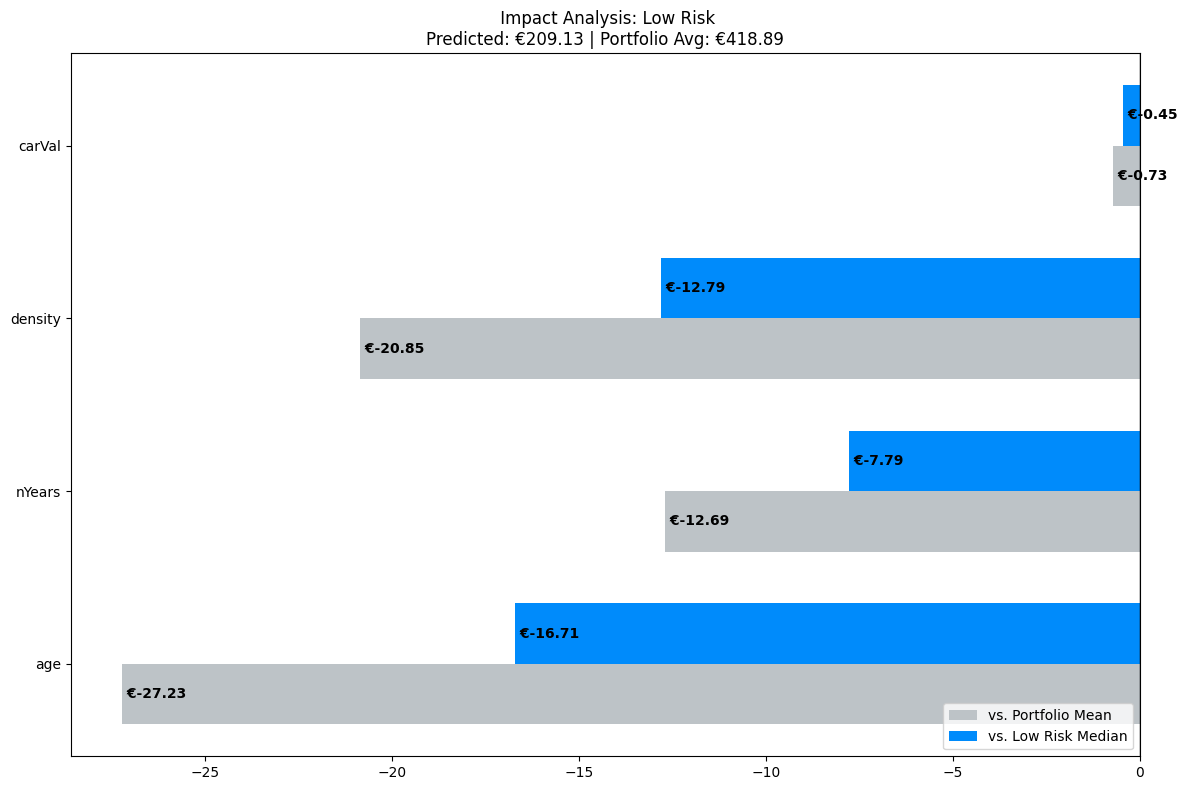

In [114]:
def shap_man(customer_data, model_freq, model_sev, tp, discretizer):
    def clean_val(val):
        if pd.isna(val): return 0.0
        s = str(val).replace('€', '').replace(',', '').replace(' inh/km²', '').strip()
        try: return float(s)
        except: return 0.0

    df_input = pd.DataFrame([customer_data])
    freq_cust = model_freq.predict(df_input).iloc[0]
    sev_cust = model_sev.predict(df_input).iloc[0]
    cost_cust = freq_cust * sev_cust
    
    cost_df = pd.DataFrame([[cost_cust]], columns=["Expected_Cost"])
    risk_bin = discretizer.transform(cost_df)[0][0]
    risk_labels = {0.0: "Low Risk", 1.0: "Medium Risk", 2.0: "High Risk"}
    risk_tier = risk_labels[risk_bin]
    
    current_tier_col = [c for c in tp.columns if risk_tier.lower() in str(c).lower()][0]
    tier_baseline_cost = clean_val(tp.loc['Median_Expected_Cost', current_tier_col])

    costs = tp.loc['Median_Expected_Cost'].apply(clean_val)
    sizes = tp.loc['Portfolio_Size'].apply(clean_val)
    portfolio_avg_cost = (costs * sizes).sum() / sizes.sum()

    coefs_f = model_freq.params
    coefs_s = model_sev.params
    features_map = {'age': 'Median_age', 'nYears': 'Median_nYears', 
                    'density': 'Median_density', 'carVal': 'Median_carVal'}
    
    labels = list(features_map.keys())
    tier_vals, port_vals = [], []

    for feat, row_label in features_map.items():
        total_coef = coefs_f.get(feat, 0) + coefs_s.get(feat, 0)
        tier_val = clean_val(tp.loc[row_label, current_tier_col])
        
        diff = customer_data[feat] - tier_val
        # exponential impact formula
        tier_impact = (np.exp(total_coef * diff) - 1) * tier_baseline_cost
        port_impact = (np.exp(total_coef * diff) - 1) * portfolio_avg_cost
        
        tier_vals.append(tier_impact)
        port_vals.append(port_impact)

    y = np.arange(len(labels))
    width = 0.35
    fig, ax = plt.subplots(figsize=(12, 8))
    
    rects1 = ax.barh(y - width/2, port_vals, width, label='vs. Portfolio Mean', color='#bdc3c7')
    rects2 = ax.barh(y + width/2, tier_vals, width, label=f'vs. {risk_tier} Median', color='#e74c3c' if risk_tier == "High Risk" else '#008bfb')

    ax.set_title(f' Impact Analysis: {risk_tier}\nPredicted: €{cost_cust:.2f} | Portfolio Avg: €{portfolio_avg_cost:.2f}')
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.legend(loc='lower right')
    ax.axvline(0, color='black', linewidth=1)
    
    for i, v in enumerate(port_vals):
        ax.text(v, i - width/2, f' €{v:.2f}', va='center', fontweight='bold')
    for i, v in enumerate(tier_vals):
        ax.text(v, i + width/2, f' €{v:.2f}', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

shap_man(new_customer6, model_freq_v2, model_sev_v3, tp_final, discretizer)

In [92]:
def interpret_categorical_impacts(model_freq, model_sev):

    all_features = set(model_freq.params.index) | set(model_sev.params.index)
    
    impact_data = []
    
    cat_keywords = ['gender', 'job', 'carType', 'carCat', 'employment']
    
    for feat in all_features:
        if any(key in feat for key in cat_keywords):
            coef_f = model_freq.params.get(feat, 0)
            coef_s = model_sev.params.get(feat, 0)
            
            total_log_coef = coef_f + coef_s
            
            pct_change = (np.exp(total_log_coef) - 1) * 100
            
            impact_data.append({
                'Feature_Level': feat,
                'Log_Coef_Total': total_log_coef,
                'Percentage_Impact': f"{pct_change:+.2f}%"
            })
            
    df_impact = pd.DataFrame(impact_data).sort_values(by='Log_Coef_Total', ascending=False)
    
    print("--- Categorical Risk Interpretation ---")
    print("Positive % = Increases Risk | Negative % = Decreases Risk")
    return df_impact

cat_analysis = interpret_categorical_impacts(model_freq_v2, model_sev_v3)
print(cat_analysis)

--- Categorical Risk Interpretation ---
Positive % = Increases Risk (Penalty) | Negative % = Decreases Risk (Bonus)
          Feature_Level  Log_Coef_Total Percentage_Impact
2     job[T.Unemployed]        0.330285           +39.14%
0        gender[T.Male]        0.243712           +27.60%
3        job[T.Retired]        0.173958           +19.00%
5          carType[T.B]        0.012246            +1.23%
1      job[T.Housewife]       -0.010495            -1.04%
8  job[T.Self-employed]       -0.016413            -1.63%
7          carType[T.C]       -0.043906            -4.30%
6          carType[T.E]       -0.066617            -6.44%
4          carType[T.D]       -0.101425            -9.65%


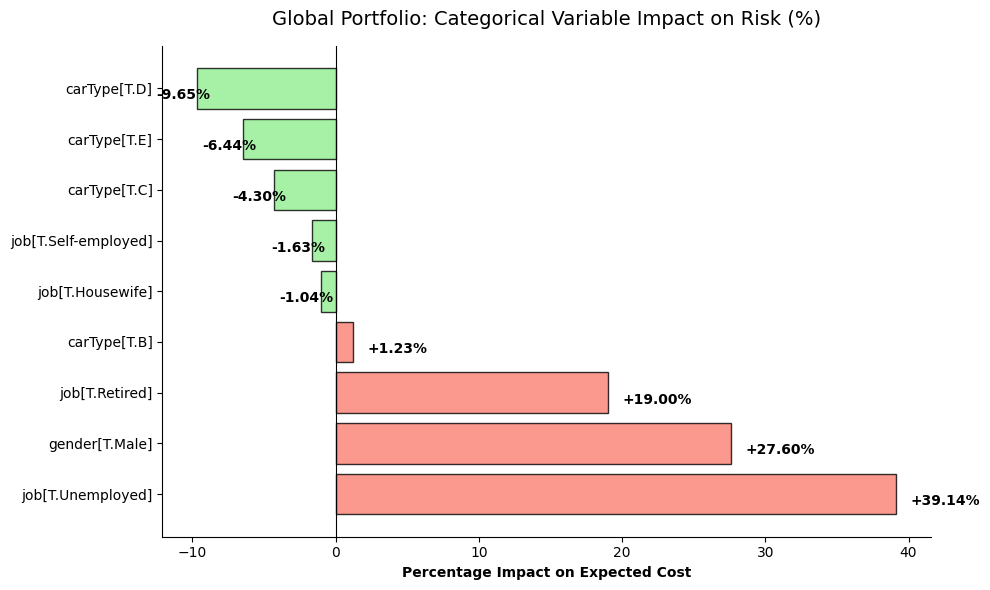

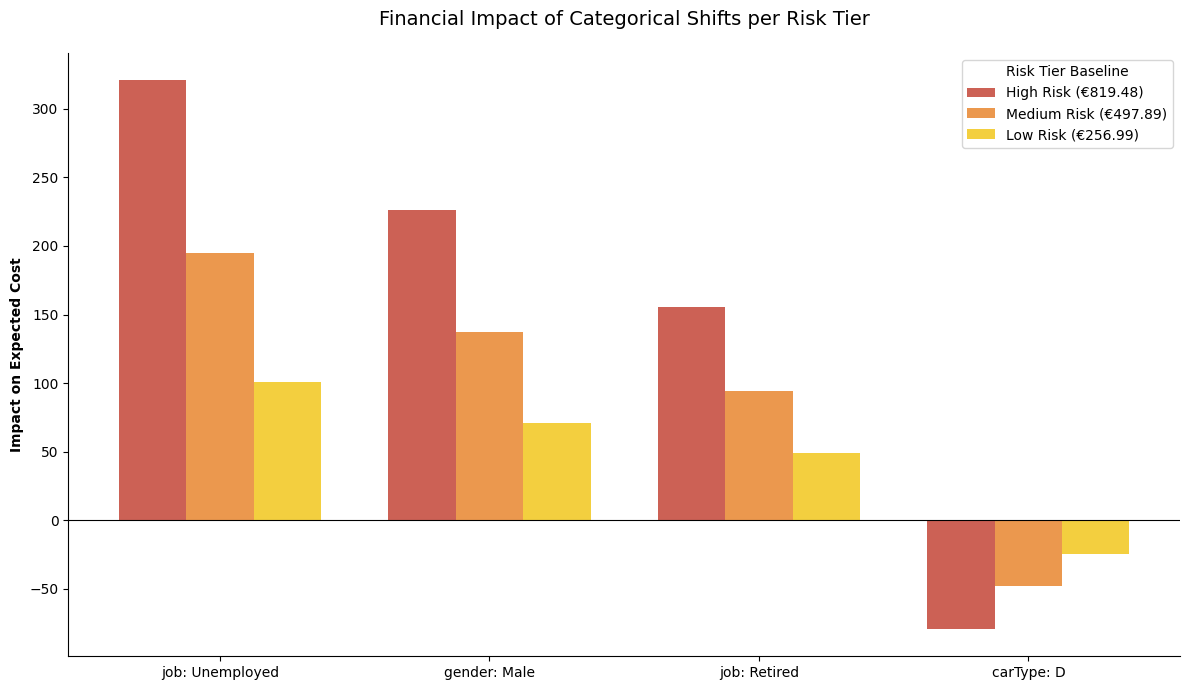

In [106]:
global_data = {
    'Feature_Level': [
        'job[T.Unemployed]', 'gender[T.Male]', 'job[T.Retired]', 
        'carType[T.B]', 'job[T.Housewife]', 'job[T.Self-employed]', 
        'carType[T.C]', 'carType[T.E]', 'carType[T.D]'
    ],
    'Pct_Impact': [39.14, 27.60, 19.00, 1.23, -1.04, -1.63, -4.30, -6.44, -9.65]
}
df_global = pd.DataFrame(global_data).sort_values('Pct_Impact', ascending=False)

tier_baselines = {
    'High Risk': 819.48,
    'Medium Risk': 497.89,
    'Low Risk': 256.99
}


def plot_global_categorical_risk(df):
    plt.figure(figsize=(10, 6))
    colors = ['salmon' if x > 0 else 'lightgreen' for x in df['Pct_Impact']]
    
    bars = plt.barh(df['Feature_Level'], df['Pct_Impact'], color=colors, edgecolor='black', alpha=0.8)
    
    for bar in bars:
        width = bar.get_width()
        plt.text(width + (1 if width > 0 else -1), bar.get_y() + bar.get_height()/2, 
                 f'{width:+.2f}%', va='top', fontweight='bold', 
                 ha='left' if width > 0 else 'center')
        
    plt.title('Global Portfolio: Categorical Variable Impact on Risk (%)', fontsize=14, pad=15)
    plt.xlabel('Percentage Impact on Expected Cost', fontweight='bold')
    plt.axvline(0, color='black', linewidth=0.8)
    plt.gca().spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

def plot_tier_financial_impact(df, baselines):
    top_vars = ['job[T.Unemployed]', 'gender[T.Male]', 'job[T.Retired]', 'carType[T.D]']
    df_sub = df[df['Feature_Level'].isin(top_vars)].copy()
    
    tier_impacts = {}
    for tier_name, baseline_val in baselines.items():
        tier_impacts[tier_name] = (df_sub['Pct_Impact'] / 100) * baseline_val

    x = np.arange(len(top_vars))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    ax.bar(x - width, tier_impacts['High Risk'], width, label=f'High Risk (€{baselines["High Risk"]})', color='#c0392b', alpha=0.8)
    ax.bar(x, tier_impacts['Medium Risk'], width, label=f'Medium Risk (€{baselines["Medium Risk"]})', color='#e67e22', alpha=0.8)
    ax.bar(x + width, tier_impacts['Low Risk'], width, label=f'Low Risk (€{baselines["Low Risk"]})', color='#f1c40f', alpha=0.8)

    ax.set_ylabel('Impact on Expected Cost', fontweight='bold')
    ax.set_title('Financial Impact of Categorical Shifts per Risk Tier', fontsize=14, pad=20)
    
    clean_labels = [v.replace('[T.', ': ').replace(']', '') for v in top_vars]
    ax.set_xticks(x)
    ax.set_xticklabels(clean_labels)
    
    ax.legend(title="Risk Tier Baseline")
    ax.axhline(0, color='black', linewidth=0.8)
    ax.spines[['top', 'right']].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# 3. RUN ANALYSES
plot_global_categorical_risk(df_global)
plot_tier_financial_impact(df_global, tier_baselines)

C:\Users\athul\AppData\Local\Temp\ipykernel_6776\3362060061.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_summary_pct = (df_sorted.groupby('decile')[cost_column].sum() / total_loss) * 100


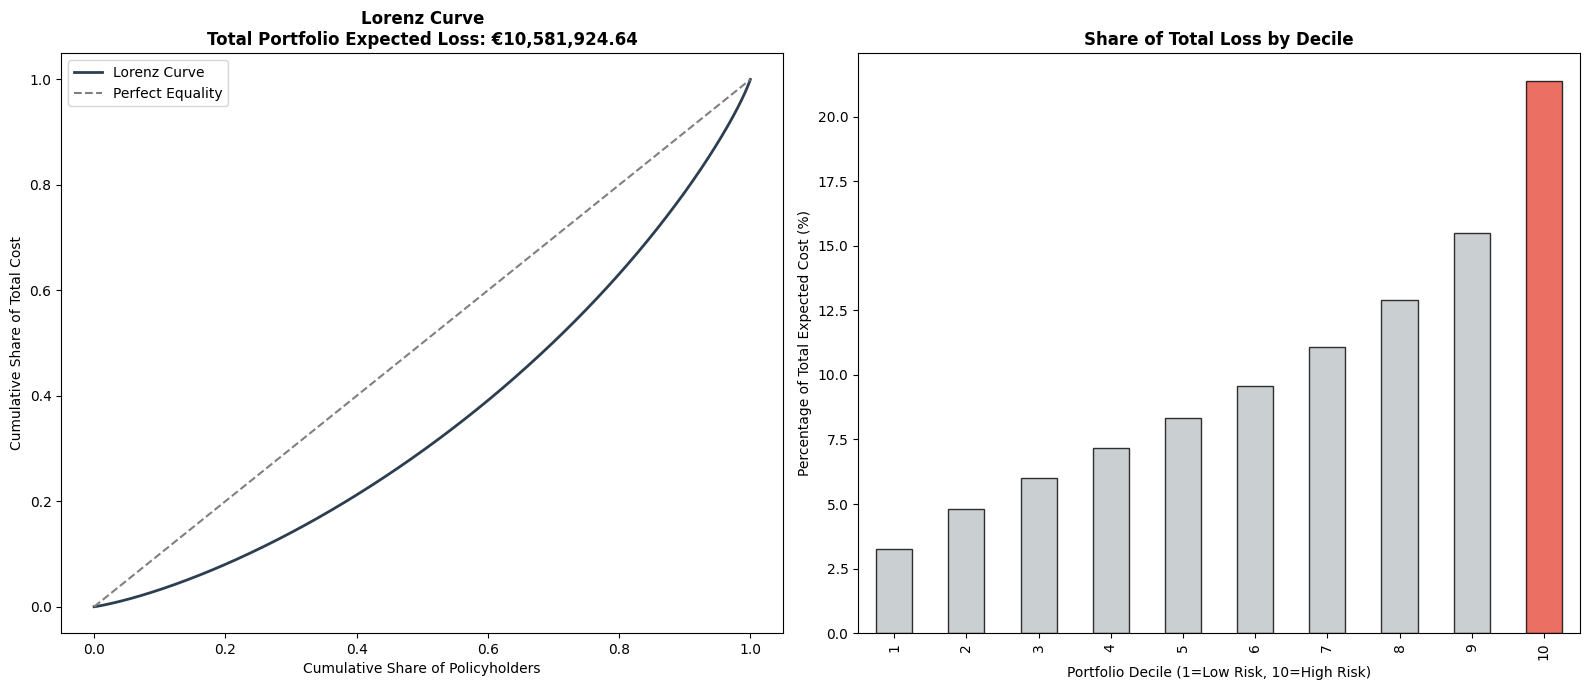

In [110]:
def analyze_portfolio_deciles_v3(df, cost_column):
    #Global Statistics
    total_loss = df[cost_column].sum()
    global_mean = df[cost_column].mean()
    n = len(df)
    
    # Sort and Calculate Lorenz
    df_sorted = df.sort_values(cost_column).reset_index(drop=True)
    cum_people = np.arange(1, n + 1) / n
    cum_costs = df_sorted[cost_column].cumsum() / total_loss
    
    # Decile Aggregation
    df_sorted['decile'] = pd.qcut(df_sorted.index, 10, labels=np.arange(1, 11))
    decile_summary_pct = (df_sorted.groupby('decile')[cost_column].sum() / total_loss) * 100
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    ax1.plot(cum_people, cum_costs, color='#2c3e50', lw=2, label='Lorenz Curve')
    ax1.plot([0, 1], [0, 1], '--', color='grey', label='Perfect Equality')
    ax1.set_title(f'Lorenz Curve\nTotal Portfolio Expected Loss: €{total_loss:,.2f}', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Cumulative Share of Policyholders')
    ax1.set_ylabel('Cumulative Share of Total Cost')
    ax1.legend()
    
    colors = ['#bdc3c7'] * 9 + ['#e74c3c'] 
    decile_summary_pct.plot(kind='bar', ax=ax2, color=colors, edgecolor='black', alpha=0.8)
    
    
    ax2.set_title('Share of Total Loss by Decile', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Portfolio Decile (1=Low Risk, 10=High Risk)')
    ax2.set_ylabel('Percentage of Total Expected Cost (%)')
    
    plt.tight_layout()
    plt.show()

analyze_portfolio_deciles_v3(df_frequency, 'Expected_Cost')

In [108]:
def run_backtest_analysis(df, pred_col, actual_col):
    
    df = df.sort_values(pred_col).reset_index(drop=True)
    df['decile'] = pd.qcut(df.index, 10, labels=range(1, 11))
    
    high_risk = df[df['decile'] == 10]
    safe_group = df[df['decile'].isin([1, 2, 3])]
    
    results = pd.DataFrame({
        'Group': ['Safe (D1-3)', 'High Risk (D10)'],
        'Avg Actual Loss (€)': [safe_group[actual_col].mean(), high_risk[actual_col].mean()],
        'Total Actual Loss (€)': [safe_group[actual_col].sum(), high_risk[actual_col].sum()]
    })
    
    multiplier = high_risk[actual_col].mean() / safe_group[actual_col].mean()
    print(f"The High-Risk group is {multiplier:.1f}x riskier than the Safe group.")
    
    return results

backtest_results = run_backtest_analysis(df_frequency, 'Expected_Cost', 'actual_cost')